In [10]:
import DBD_1
import pandas as pd
import numpy as np
import time
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

In [2]:
petrol_df = DBD_1.load_petrol()
petrol_df["Total_Production_Lag1"] = petrol_df["Total_Production"].shift(1)
deisel_df = DBD_1.load_diesel()
deisel_df["Total_Production_Lag1"] = deisel_df["Total_Production"].shift(1)

FORECAST_HORIZON = 1
TRAIN_RATIO = 0.8

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [3]:
ARIMA_ORDER = (2, 1, 5)
ARIMA_WEIGHT = 0.4           # blend weight: mixed = ARIMA_WEIGHT * arima_pred + (1 - ARIMA_WEIGHT) * prophet_pred

In [16]:
from sklearn.linear_model import LinearRegression

def run_mixed_model(df, feature_cols, lr_feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.25, NAIVE_WEIGHT=0.15, GBM_WEIGHT=0.2, LR_WEIGHT=0.15,
                     gbm_n_estimators=200, gbm_max_depth=3, gbm_learning_rate=0.05,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive + GBM + Linear
    Regression model using rolling-origin (walk-forward) validation.

    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using all of `feature_cols`, held at the current row.
    - Naive forecasts the last known observed price, unchanged.
    - GBM predicts using the same (features_t -> target_{t+H}) pairing as Prophet.
    - Linear Regression predicts using ONLY `lr_feature_cols` — a deliberately
      restricted subset, since LR is prone to instability with many collinear
      lagged features.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of regressor columns used by Prophet and GBM
    lr_feature_cols : list of regressor columns used by Linear Regression only
    """
    if ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT must not "
                          "exceed 1 (remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT - GBM_WEIGHT - LR_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]
    lr_feature_cols = [c for c in lr_feature_cols if c not in ("Date", target_col)]

    missing = [c for c in lr_feature_cols if c not in feature_cols and c not in df.columns]
    if missing:
        raise ValueError(f"lr_feature_cols contains columns not found in df: {missing}")

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    # union of both feature sets, so both Prophet/GBM and LR have what they need
    all_needed_cols = list(dict.fromkeys(feature_cols + lr_feature_cols))

    prophet_df = data[["Date", target_col] + all_needed_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list = [], [], []
    naive_pred_list, gbm_pred_list, lr_pred_list = [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]
        level_fold = prophet_df.iloc[:i + 1]
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        naive_pred = level_fold["y_level"].iloc[-1]

        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_pred = arima_fitted.forecast(steps=FORECAST_HORIZON).iloc[-1]

        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])
        prophet_pred = prophet_model.predict(test_row[["ds"] + feature_cols])["yhat"].values[0]

        gbm_model = GradientBoostingRegressor(
            n_estimators=gbm_n_estimators, max_depth=gbm_max_depth,
            learning_rate=gbm_learning_rate, subsample=0.8, random_state=42
        )
        gbm_model.fit(train_fold[feature_cols], train_fold["y"])
        gbm_pred = gbm_model.predict(test_row[feature_cols])[0]

        lr_model = LinearRegression()
        lr_model.fit(train_fold[lr_feature_cols], train_fold["y"])
        lr_pred = lr_model.predict(test_row[lr_feature_cols])[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred +
            GBM_WEIGHT * gbm_pred +
            LR_WEIGHT * lr_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)
        gbm_pred_list.append(gbm_pred)
        lr_pred_list.append(lr_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(mixed_pred_list)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
        "gbm_pred": gbm_pred_list,
        "lr_pred": lr_pred_list,
    })

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    naive_rmse = root_mean_squared_error(y_true, results_df["naive_pred"])
    naive_mae = mean_absolute_error(y_true, results_df["naive_pred"])
    lr_rmse = root_mean_squared_error(y_true, results_df["lr_pred"])

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) + GBM(w={GBM_WEIGHT}) + LR(w={LR_WEIGHT}) | "
          f"horizon={FORECAST_HORIZON}m | include_2026={include_2026} | "
          f"walk-forward steps={len(results_df)}")
    print(f"RMSE: {rmse:.4f}  |  Naive-only RMSE: {naive_rmse:.4f}  |  LR-only RMSE: {lr_rmse:.4f}")
    print(f"MAE:  {mae:.4f}  |  Naive-only MAE:  {naive_mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(results_df["ds"], results_df["y_true"], label="Actual", marker="o")
        ax.plot(results_df["ds"], results_df["y_pred"], label="Mixed", marker="o")
        ax.plot(results_df["ds"], results_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.plot(results_df["ds"], results_df["gbm_pred"], label="GBM only", alpha=0.4, linestyle="-.")
        ax.plot(results_df["ds"], results_df["lr_pred"], label="LR only", alpha=0.4, linestyle=(0, (1, 1)))
        ax.legend()
        ax.set_title(f"Mixed Model — {target_col} rolling {FORECAST_HORIZON}m-ahead "
                     f"(ARIMA={ARIMA_WEIGHT}, Naive={NAIVE_WEIGHT}, GBM={GBM_WEIGHT}, "
                     f"LR={LR_WEIGHT}, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "naive_rmse": naive_rmse, "naive_mae": naive_mae, "lr_rmse": lr_rmse,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "gbm_model": gbm_model,
        "lr_model": lr_model,
        "results_df": results_df,
        "train_df": train_fold,
    }

All selected features per horizon (Petrol):

In [14]:
features_1M_lr = ['USDZAR_LastWeekMean', 'Brent_LastWeekMean', 'BFP', 'Total_Production_Lag1']

In [5]:
features_1M_petrol = ['BFP', 'BFP_Delta_Lag2', 'GECON', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'Brent_LastWeekStd_Lag2', 'USDZAR_LastWeekMean', 'Brent_MonthMean', 'Brent_LastWeekMean_Lag2', 'GPR_Lag2']
features_2M_petrol = ['BFP', 'BFP_Delta_Lag1', 'GSCPI_Lag12', 'GPR_Lag6', 'GECON', 'GECON_Lag3', 'GPR', 'BFP_Delta_Lag4']
features_3M_petrol = ['BFP', 'GSCPI_Lag12', 'BFP_Delta_Lag1', 'GPR_Lag6', 'GECON', 'INDPRO', 'BFP_Lag2', 'Brent_LastWeekStd', 'BFP_Lag6', 'BFP_Delta_Lag3']
features_4M_petrol = ['GSCPI_Lag12', 'BFP_Lag1', 'GPR_Lag6', 'BFP_Delta_Lag2', 'GECON', 'USDZAR_Std', 'Brent_LastWeekStd_Lag3', 'GECON_Lag1', 'Brent_MonthStd', 'USDZAR_Delta_Lag2']
features_5M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag1', 'Brent_LastWeekStd_Lag3', 'Total_Production_Lag1']
features_6M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag5', 'Brent_LastWeekStd_Lag2', 'GPR_Lag2', 'BFP_Delta_Lag4']

All selected features per horizon (Diesel):

In [6]:
features_1M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_LastWeekMean_Lag2', 'Total_Production_Lag1', 'USDZAR_LastWeekMean', 'USDZAR_Mean_Lag1', 'BFP_Delta_Lag5', 'BFP_Delta_Lag1', 'BFP_Lag1', 'Brent_MonthMean_Lag1']
features_2M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'BFP_Delta_Lag1', 'Brent_MonthStd', 'GSCPI_Lag12', 'USDZAR_LastWeekMean', 'GECON_Lag3', 'USDZAR_Mean_Lag1', 'Brent_MonthMean']
features_3M_diesel = ['BFP', 'GSCPI_Lag12', 'GPR_Lag6', 'BFP_Delta_Lag1', 'Brent_LastWeekStd', 'GECON_Lag3', 'USDZAR_Delta_Lag1']
features_4M_diesel = ['GSCPI_Lag12', 'BFP_Lag2', 'GPR_Lag6', 'USDZAR_Delta_Lag2']
features_5M_diesel = ['GSCPI_Lag12']
features_6M_diesel = ['GSCPI_Lag12', 'GECON', 'GPR_Lag6']

## 1 Month Ahead

12:15:05 - cmdstanpy - INFO - Chain [1] start processing
12:15:05 - cmdstanpy - INFO - Chain [1] done processing
12:15:05 - cmdstanpy - INFO - Chain [1] start processing
12:15:05 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:15:06 - cmdstanpy - INFO - Chain [1] start processing
12:15:06 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:15:06 - cmdstanpy - INFO - Chain [1] start processing
12:15:06 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.25) + Prophet(w=0.25) + Naive(w=0.15) + GBM(w=0.2) + LR(w=0.15) | horizon=1m | include_2026=True | walk-forward steps=36
RMSE: 143.3935  |  Naive-only RMSE: 206.3716  |  LR-only RMSE: 168.8223
MAE:  87.6999  |  Naive-only MAE:  128.4717
R2:   0.7805


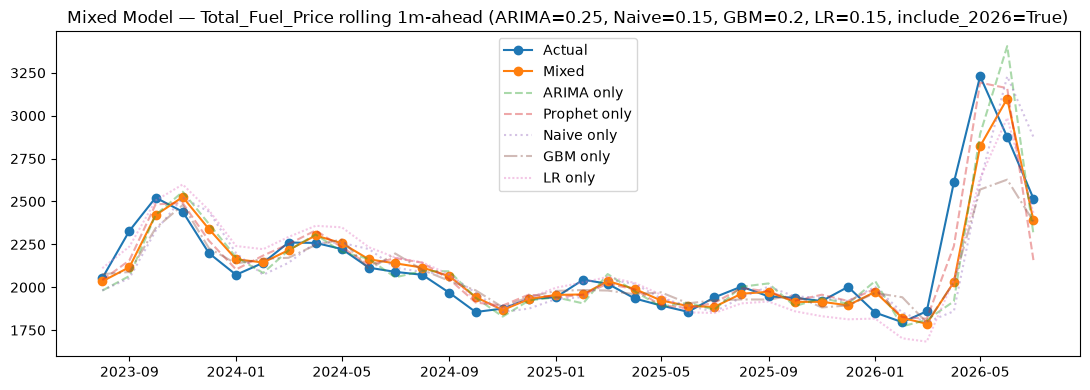

In [24]:
results = run_mixed_model(deisel_df, features_1M_diesel, features_1M_lr)

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:14:03 - cmdstanpy - INFO - Chain [1] start processing
Python(62264) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:14:03 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:14:03 - cmdstanpy - INFO - Chain [1] start processing
Python(62265) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:14:03 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/U

Mixed Model — ARIMA(w=0.05) + Prophet(w=0.95) + Naive(w=0) + GBM(w=0) | horizon=1m | include_2026=True | walk-forward steps=37
RMSE: 51.0279  |  Naive-only RMSE: 109.9339
MAE:  40.5011  |  Naive-only MAE:  79.4270
R2:   0.9239


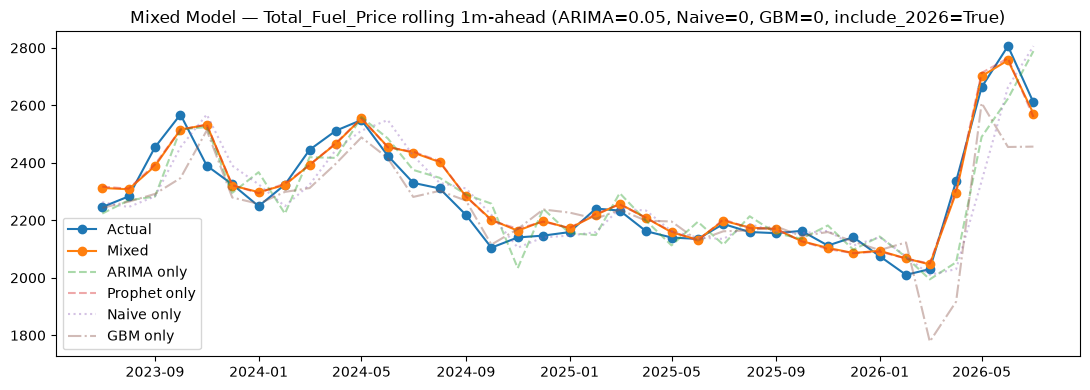

In [121]:
results = run_mixed_model(petrol_df, features_1M_petrol, FORECAST_HORIZON=1, ARIMA_WEIGHT=0.05, NAIVE_WEIGHT=0, GBM_WEIGHT=0)

## 2 Months Ahead

13:55:26 - cmdstanpy - INFO - Chain [1] start processing
13:55:26 - cmdstanpy - INFO - Chain [1] done processing
13:55:26 - cmdstanpy - INFO - Chain [1] start processing
13:55:26 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:55:27 - cmdstanpy - INFO - Chain [1] start processing
13:55:27 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
13:55:27 - cmdstanpy - INFO - Chain [1] start processing
13:55:27 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.4) + Prophet(w=0.40) + Naive(w=0.2) | horizon=2m | include_2026=True | walk-forward steps=35
RMSE: 267.0447  |  Naive-only RMSE: 338.8699
MAE:  160.6486  |  Naive-only MAE:  206.1206
R2:   0.2585


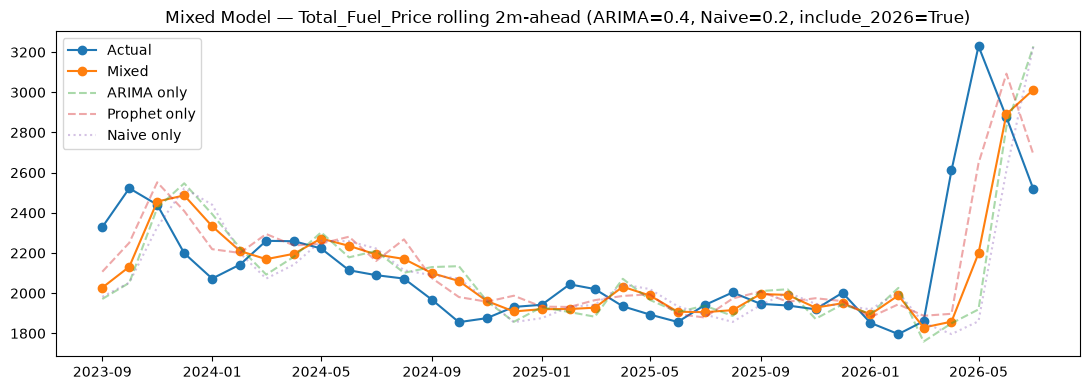

In [69]:
results = run_mixed_model(deisel_df, features_2M_diesel, FORECAST_HORIZON=2)

## 3 Months Ahead

## 4 Months Ahead

## 5 Months Ahead

## 6 Months Ahead

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done processing
14:17:31 - cmdstanpy - INFO - Chain [1] start processing
14:17:31 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0.4) + Prophet(w=0.40) + Naive(w=0.2) | horizon=6m | include_2026=True | walk-forward steps=34
RMSE: 322.5231  |  Naive-only RMSE: 361.2640
MAE:  206.7194  |  Naive-only MAE:  228.4762
R2:   -0.0636


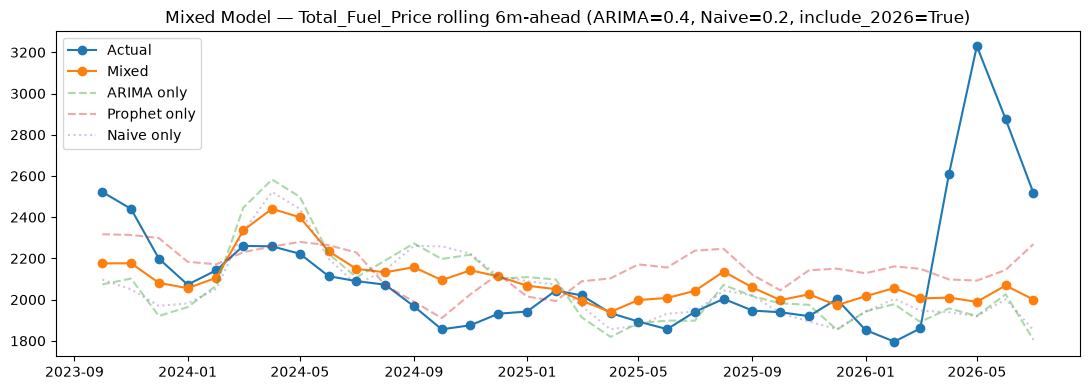

In [75]:
results = run_mixed_model(deisel_df, features_6M_diesel, FORECAST_HORIZON=6)

In [100]:
results['results_df']

,ds,y_true,y_pred,arima_pred,prophet_pred,naive_pred
0,2023-10-01,2522.39,2175.898098,2073.967457,2317.162788,2097.23
1,2023-11-01,2440.31,2176.291601,2101.975716,2313.908287,2049.69
2,2023-12-01,2198.89,2081.635908,1920.642790,2298.601980,1969.69
3,2024-01-01,2072.57,2055.313670,1963.684866,2183.754310,1981.69
4,2024-02-01,2142.57,2106.044358,2067.614480,2171.151414,2052.69
5,2024-03-01,2260.57,2336.101893,2445.593239,2230.316495,2328.69
6,2024-04-01,2258.59,2440.600884,2582.782233,2257.524978,2522.39
7,2024-05-01,2222.59,2399.494702,2498.690121,2279.891635,2440.31
8,2024-06-01,2114.05,2234.507522,2222.671992,2264.151813,2198.89
9,2024-07-01,2089.67,2149.199169,2108.005588,2228.707334,2072.57


## Weighting formulations based on whole test set

In [18]:
def get_walkforward_predictions(df, feature_cols, lr_feature_cols, target_col="Total_Fuel_Price",
                                 FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                                 gbm_n_estimators=200, gbm_max_depth=3, gbm_learning_rate=0.05,
                                 include_2026=True):
    """
    Runs the walk-forward loop once and returns raw predictions from ARIMA,
    Prophet, Naive, GBM, and Linear Regression — no blending applied yet.
    Reuse this output to search weight combinations cheaply.

    Parameters
    ----------
    feature_cols    : regressor columns used by Prophet and GBM
    lr_feature_cols : regressor columns used by Linear Regression only
    """
    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]
    lr_feature_cols = [c for c in lr_feature_cols if c not in ("Date", target_col)]

    missing = [c for c in lr_feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"lr_feature_cols contains columns not found in df: {missing}")

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    # union of both feature sets, so both Prophet/GBM and LR have what they need
    all_needed_cols = list(dict.fromkeys(feature_cols + lr_feature_cols))

    prophet_df = data[["Date", target_col] + all_needed_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))
    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    arima_pred_list, prophet_pred_list, naive_pred_list = [], [], []
    gbm_pred_list, lr_pred_list = [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]           # (features, shifted target) pairs — Prophet/GBM/LR
        level_fold = prophet_df.iloc[:i + 1]        # raw price series through row i's own actual
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        naive_pred = level_fold["y_level"].iloc[-1]

        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_pred = arima_fitted.forecast(steps=FORECAST_HORIZON).iloc[-1]

        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])
        prophet_pred = prophet_model.predict(test_row[["ds"] + feature_cols])["yhat"].values[0]

        gbm_model = GradientBoostingRegressor(
            n_estimators=gbm_n_estimators, max_depth=gbm_max_depth,
            learning_rate=gbm_learning_rate, subsample=0.8, random_state=42
        )
        gbm_model.fit(train_fold[feature_cols], train_fold["y"])
        gbm_pred = gbm_model.predict(test_row[feature_cols])[0]

        lr_model = LinearRegression()
        lr_model.fit(train_fold[lr_feature_cols], train_fold["y"])
        lr_pred = lr_model.predict(test_row[lr_feature_cols])[0]

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)
        gbm_pred_list.append(gbm_pred)
        lr_pred_list.append(lr_pred)

    return pd.DataFrame({
        "ds": dates,
        "y_true": y_true_list,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
        "gbm_pred": gbm_pred_list,
        "lr_pred": lr_pred_list,
    })

In [19]:
def find_best_weights(preds_df, step=0.1, metric="rmse"):
    y_true = preds_df["y_true"].values
    arima = preds_df["arima_pred"].values
    prophet = preds_df["prophet_pred"].values
    naive = preds_df["naive_pred"].values
    gbm = preds_df["gbm_pred"].values
    lr = preds_df["lr_pred"].values

    weights = np.round(np.arange(0, 1 + step, step), 4)
    results = []

    for aw in weights:
        for nw in weights:
            for gw in weights:
                for lw in weights:
                    pw = round(1 - aw - nw - gw - lw, 4)
                    if pw < 0:
                        continue

                    mixed = aw * arima + pw * prophet + nw * naive + gw * gbm + lw * lr

                    rmse = root_mean_squared_error(y_true, mixed)
                    mae = mean_absolute_error(y_true, mixed)
                    r2 = r2_score(y_true, mixed)
                    dir_acc = (np.sign(np.diff(y_true)) == np.sign(np.diff(mixed))).mean()

                    results.append({
                        "ARIMA_WEIGHT": aw, "PROPHET_WEIGHT": pw,
                        "NAIVE_WEIGHT": nw, "GBM_WEIGHT": gw, "LR_WEIGHT": lw,
                        "rmse": rmse, "mae": mae, "r2": r2, "directional_accuracy": dir_acc,
                    })

    results_df = pd.DataFrame(results)
    best = (results_df.sort_values("rmse").iloc[0] if metric == "rmse"
            else results_df.sort_values("directional_accuracy", ascending=False).iloc[0])

    return best, results_df

## Weighting formulations - kept all that didn't just say use Prophet

In [22]:
preds_df = get_walkforward_predictions(deisel_df, features_1M_diesel, features_1M_lr,
                                        FORECAST_HORIZON=1, TRAIN_RATIO=0.8)

best_weights, weight_grid = find_best_weights(preds_df, step=0.05, metric="rmse")

# top 10 configs, for context/sensitivity checking
weight_grid.sort_values("rmse").head(3)

12:09:16 - cmdstanpy - INFO - Chain [1] start processing
12:09:16 - cmdstanpy - INFO - Chain [1] done processing
12:09:16 - cmdstanpy - INFO - Chain [1] start processing
12:09:16 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:09:17 - cmdstanpy - INFO - Chain [1] start processing
12:09:17 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:09:17 - cmdstanpy - INFO - Chain [1] start processing
12:09:17 - cmdstanpy - INFO - Chain [1] done proce

,ARIMA_WEIGHT,PROPHET_WEIGHT,NAIVE_WEIGHT,GBM_WEIGHT,LR_WEIGHT,rmse,mae,r2,directional_accuracy
60,0.0,0.85,0.0,0.15,0.0,111.014622,70.816483,0.868417,0.714286
41,0.0,0.90,0.0,0.10,0.0,111.238125,70.247448,0.867887,0.714286
78,0.0,0.80,0.0,0.20,0.0,111.328675,71.385519,0.867672,0.714286


In [112]:
preds_df = get_walkforward_predictions(petrol_df, features_1M_petrol,
                                        FORECAST_HORIZON=1, TRAIN_RATIO=0.8)

best_weights, weight_grid = find_best_weights(preds_df, step=0.05, metric="rmse")

# top 3 configs, for context/sensitivity checking
weight_grid.sort_values("rmse").head(3)

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:03:59 - cmdstanpy - INFO - Chain [1] start processing
Python(55473) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:03:59 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:03:59 - cmdstanpy - INFO - Chain [1] start processing
Python(55474) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:03:59 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/U

,ARIMA_WEIGHT,PROPHET_WEIGHT,NAIVE_WEIGHT,GBM_WEIGHT,rmse,mae,r2,directional_accuracy
231,0.05,0.95,0.00,0.0,51.027946,40.501066,0.923879,0.75
441,0.10,0.90,0.00,0.0,51.131612,40.308612,0.923569,0.75
21,0.00,0.95,0.05,0.0,51.211720,40.419511,0.923330,0.75


In [113]:
preds_df = get_walkforward_predictions(deisel_df, features_6M_diesel,
                                        FORECAST_HORIZON=6, TRAIN_RATIO=0.8)

best_weights, weight_grid = find_best_weights(preds_df, step=0.05, metric="rmse")

# top 3 configs, for context/sensitivity checking
weight_grid.sort_values("rmse").head(3)

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:04:28 - cmdstanpy - INFO - Chain [1] start processing
Python(55844) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:04:28 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:04:29 - cmdstanpy - INFO - Chain [1] start processing
Python(55845) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:04:29 - cmdstanpy - INFO - Chain [1] done processing
11:04:29 - cmdstanpy - I

,ARIMA_WEIGHT,PROPHET_WEIGHT,NAIVE_WEIGHT,GBM_WEIGHT,rmse,mae,r2,directional_accuracy
3,0.00,0.85,0.00,0.15,291.122191,182.251725,0.133441,0.606061
234,0.05,0.80,0.00,0.15,291.779653,179.021328,0.129522,0.636364
24,0.00,0.80,0.05,0.15,292.088229,179.504976,0.127680,0.636364


## Weightings based on a rolling one year window

In [114]:
def get_rolling_windows(preds_df, window_size=12, n_windows=3):
    """
    Splits the most recent `n_windows` non-overlapping `window_size`-month
    blocks out of preds_df, most recent last. Returns a list of DataFrames.
    """
    df = preds_df.sort_values("ds").reset_index(drop=True)
    needed = window_size * n_windows

    if len(df) < needed:
        raise ValueError(f"Need at least {needed} predictions for {n_windows} "
                          f"windows of {window_size} months, only have {len(df)}.")

    df = df.iloc[-needed:].reset_index(drop=True)  # keep only the most recent n_windows*window_size rows

    windows = []
    for w in range(n_windows):
        start = w * window_size
        end = start + window_size
        windows.append(df.iloc[start:end].reset_index(drop=True))

    return windows


def find_best_weights_rolling(preds_df, window_size=12, n_windows=3, step=0.1, metric="rmse"):
    windows = get_rolling_windows(preds_df, window_size=window_size, n_windows=n_windows)

    weights = np.round(np.arange(0, 1 + step, step), 4)
    results = []

    for aw in weights:
        for nw in weights:
            for gw in weights:
                pw = round(1 - aw - nw - gw, 4)
                if pw < 0:
                    continue

                window_rmses, window_maes, window_r2s, window_dir_accs = [], [], [], []

                for w_df in windows:
                    y_true = w_df["y_true"].values
                    mixed = (
                        aw * w_df["arima_pred"].values +
                        pw * w_df["prophet_pred"].values +
                        nw * w_df["naive_pred"].values +
                        gw * w_df["gbm_pred"].values
                    )

                    window_rmses.append(root_mean_squared_error(y_true, mixed))
                    window_maes.append(mean_absolute_error(y_true, mixed))
                    window_r2s.append(r2_score(y_true, mixed) if len(y_true) > 1 else np.nan)
                    window_dir_accs.append(
                        (np.sign(np.diff(y_true)) == np.sign(np.diff(mixed))).mean() if len(y_true) > 1 else np.nan
                    )

                results.append({
                    "ARIMA_WEIGHT": aw, "PROPHET_WEIGHT": pw,
                    "NAIVE_WEIGHT": nw, "GBM_WEIGHT": gw,
                    "mean_rmse": np.mean(window_rmses),
                    "mean_mae": np.mean(window_maes),
                    "mean_r2": np.nanmean(window_r2s),
                    "mean_directional_accuracy": np.nanmean(window_dir_accs),
                    "rmse_per_window": window_rmses,
                })

    results_df = pd.DataFrame(results)
    best = (results_df.sort_values("mean_rmse").iloc[0] if metric == "rmse"
            else results_df.sort_values("mean_directional_accuracy", ascending=False).iloc[0])

    return best, results_df

In [117]:
preds_df = get_walkforward_predictions(deisel_df, features_1M_diesel,
                                        FORECAST_HORIZON=1, TRAIN_RATIO=0.8, include_2026=True)

best_weights, weight_grid = find_best_weights_rolling(preds_df, window_size=6, n_windows=6, step=0.05)
print(best_weights[["ARIMA_WEIGHT", "PROPHET_WEIGHT", "NAIVE_WEIGHT", "GBM_WEIGHT", "mean_rmse"]])

11:07:30 - cmdstanpy - INFO - Chain [1] start processing
Python(57929) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:07:30 - cmdstanpy - INFO - Chain [1] done processing
11:07:31 - cmdstanpy - INFO - Chain [1] start processing
Python(57930) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:07:31 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:07:31 - cmdstanpy - INFO - Chain [1] start processing
Python(57931) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
11:07:31 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-pack

ARIMA_WEIGHT            0.0
PROPHET_WEIGHT         0.85
NAIVE_WEIGHT            0.0
GBM_WEIGHT             0.15
mean_rmse         89.686216
Name: 3, dtype: object


In [103]:
window_dates = get_rolling_windows(preds_df, window_size=6, n_windows=6)
for i, w in enumerate(window_dates):
    print(f"Window {i+1}: {w['ds'].min().date()} to {w['ds'].max().date()}")

print("RMSE per window for best weights:", best_weights["rmse_per_window"])

Window 1: 2023-08-01 to 2024-01-01
Window 2: 2024-02-01 to 2024-07-01
Window 3: 2024-08-01 to 2025-01-01
Window 4: 2025-02-01 to 2025-07-01
Window 5: 2025-08-01 to 2026-01-01
Window 6: 2026-02-01 to 2026-07-01
RMSE per window for best weights: [81.67499202070728, 48.35222543831498, 50.397254560345985, 44.4407747095477, 69.1374599598765, 252.21499383793406]


In [122]:
def run_mixed_model(df, feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.4, NAIVE_WEIGHT=0.2,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive model using
    rolling-origin (walk-forward) validation — same single-step methodology
    as run_prophet_model.

    At each step:
    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using regressors held at the current row.
    - Naive forecasts the last known observed price, unchanged (persistence
      model) — the standard baseline any real model should beat.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of selected regressor column names (used by Prophet only)
    target_col    : target price column
    ARIMA_WEIGHT  : blend weight for ARIMA
    NAIVE_WEIGHT  : blend weight for the naive (persistence) forecast
    include_2026  : if False, drops all rows from 2026 onward before modelling
    plot          : if True, shows an actual vs predicted plot for the test set

    Returns
    -------
    dict with rmse, mae, r2, per-step predictions, and the final fitted models
    """
    if ARIMA_WEIGHT + NAIVE_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT must not exceed 1 "
                          "(remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    prophet_df = data[["Date", target_col] + feature_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Shifted target for horizon-ahead prediction (Prophet + evaluation target)
    # y_level (raw, unshifted) kept separately — ARIMA and the naive model both
    # need the actual price series, not the shifted version.
    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + feature_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list, naive_pred_list = [], [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]          # Prophet's (features, shifted target) training pairs — excludes row i, since row i's target is what we're predicting
        level_fold = prophet_df.iloc[:i + 1]       # raw price series through and INCLUDING row i's own known actual price
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        # --- Naive: last known ACTUAL price, i.e. row i's own price (Feb), not train_fold's last row (Jan) ---
        naive_pred = level_fold["y_level"].iloc[-1]

        # --- ARIMA: fit through row i's actual price, THEN forecast forward ---
        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_forecast = arima_fitted.forecast(steps=FORECAST_HORIZON)
        arima_pred = arima_forecast.iloc[-1]

        # --- Prophet: unchanged — trained on (features_t, target_{t+H}) pairs up to row i-1,
        # then predicted using row i's own (known) features ---
        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])

        fc = prophet_model.predict(test_row[["ds"] + feature_cols])
        prophet_pred = fc["yhat"].values[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(mixed_pred_list)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
    })

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # naive-only benchmark metrics, for comparison in the same run
    naive_rmse = root_mean_squared_error(y_true, results_df["naive_pred"])
    naive_mae = mean_absolute_error(y_true, results_df["naive_pred"])

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) | horizon={FORECAST_HORIZON}m | "
          f"include_2026={include_2026} | walk-forward steps={len(results_df)}")
    print(f"RMSE: {rmse:.4f}  |  Naive-only RMSE: {naive_rmse:.4f}")
    print(f"MAE:  {mae:.4f}  |  Naive-only MAE:  {naive_mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(results_df["ds"], results_df["y_true"], label="Actual", marker="o")
        ax.plot(results_df["ds"], results_df["y_pred"], label="Mixed", marker="o")
        ax.plot(results_df["ds"], results_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.legend()
        ax.set_title(f"Mixed Model — {target_col} rolling {FORECAST_HORIZON}m-ahead "
                     f"(ARIMA={ARIMA_WEIGHT}, Naive={NAIVE_WEIGHT}, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "naive_rmse": naive_rmse,
        "naive_mae": naive_mae,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "results_df": results_df,
        "train_df": train_fold,
    }